Dataset shape: (569, 30)

Target distribution:
 target
1    357
0    212
Name: count, dtype: int64
Missing values: 0

Train shape: (455, 30) Test shape: (114, 30)

=== MODEL PERFORMANCE ===

Logistic Regression:
   CV Accuracy: 0.9802
   Test Accuracy: 0.9825
   Precision: 0.9861
   Recall: 0.9861
   F1-Score: 0.9861
   ROC-AUC: 0.9954

Random Forest:
   CV Accuracy: 0.9538
   Test Accuracy: 0.9561
   Precision: 0.9589
   Recall: 0.9722
   F1-Score: 0.9655
   ROC-AUC: 0.9937


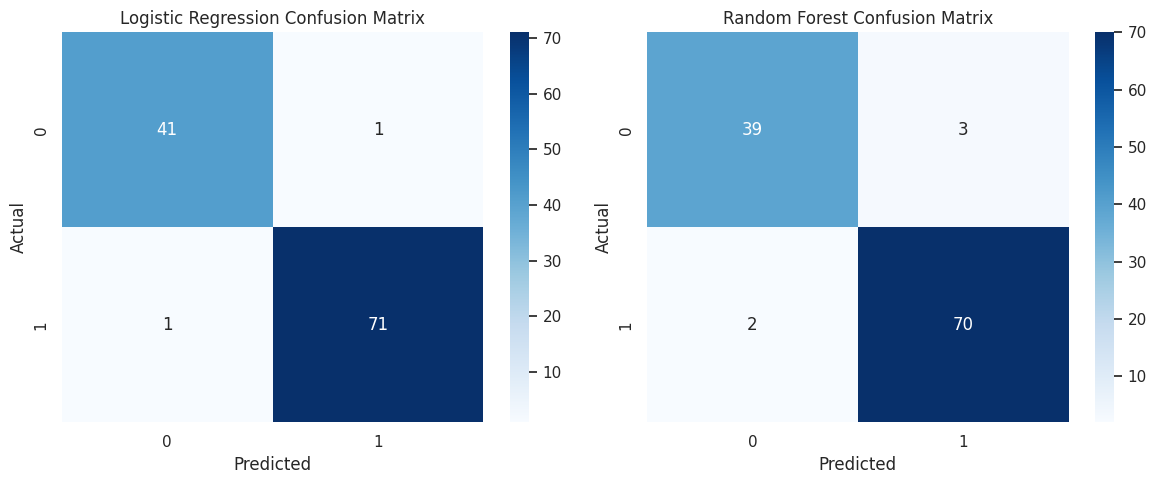

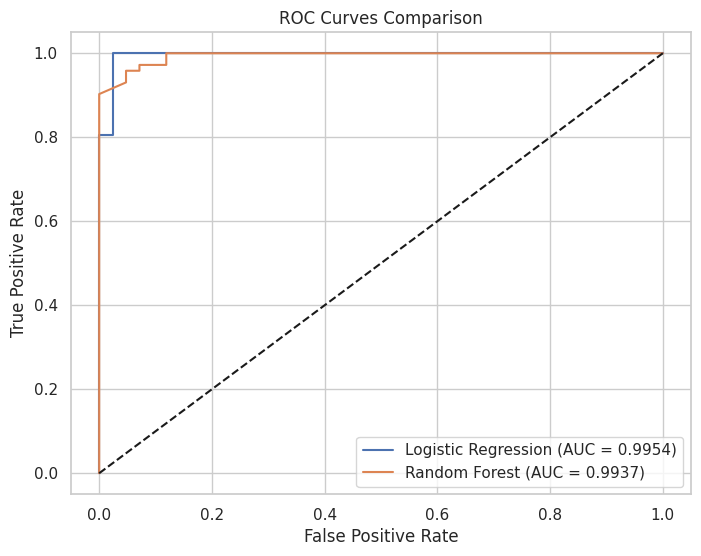

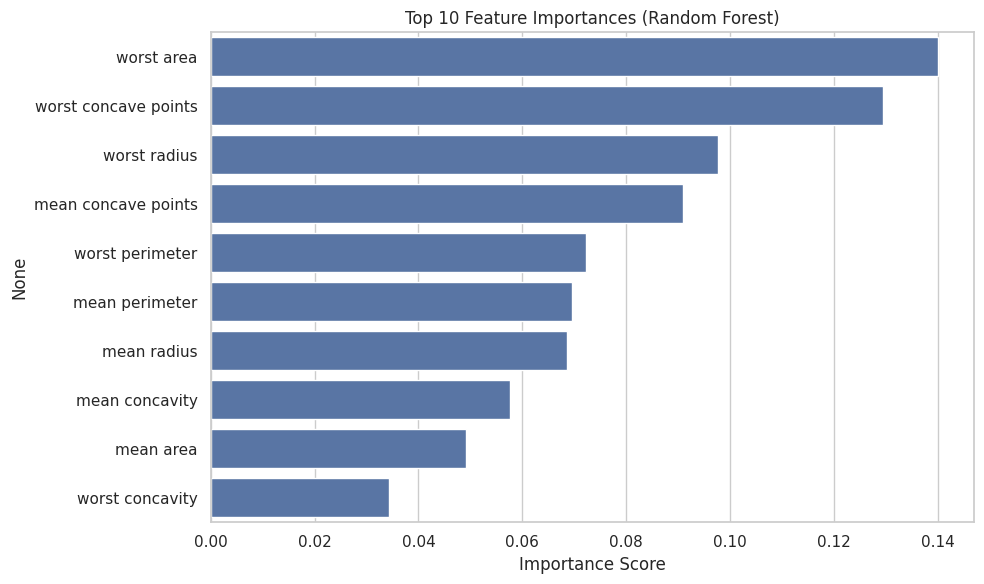


✅ All done! You should see 3 plots below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0 = malignant, 1 = benign

print("Dataset shape:", X.shape)
print("\nTarget distribution:\n", y.value_counts())
print("Missing values:", X.isnull().sum().sum())

# Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
confusion_matrices = {}
roc_data = {}

for name, model in models.items():
    # Cross Validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Train and Predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    results[name] = {
        "CV Accuracy": round(cv_scores.mean(), 4),
        "Test Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)
    }

    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, results[name]["ROC-AUC"])

# Print Results
print("\n=== MODEL PERFORMANCE ===")
for name, metrics in results.items():
    print(f"\n{name}:")
    for k, v in metrics.items():
        print(f"   {k}: {v}")

# Plot 1: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Plot 2: ROC Curves
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc_val) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

# Plot 3: Top Features (Random Forest)
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n✅ All done! You should see 3 plots below.")